# 03 Training Ablation Experiments

## 1. Goal

We compare different training choices for a tiny Arabic->English Transformer, grouped into six
categories (training objective, regularization, optimization, architecture, data, and a combined
model). Each experiment changes one thing. The notebook is runnable from scratch, but by default it loads the saved checkpoints and
results and only shows/plots them, set the flags below to actually retrain.

## 2. Imports and run flags

We import the libraries we need and fix the random seed so the runs stay repeatable.

In [1]:
import os, math, random
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import sacrebleu, sentencepiece as spm

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
torch.set_num_threads(8)
torch.manual_seed(42)
os.makedirs("outputs/figures", exist_ok=True)

These flags decide what runs. By default the notebook only loads saved results, so nothing is retrained or re scored.

In [2]:
# Default: load everything, train nothing. Flip these to rerun.
RUN_TRAINING = False     # train missing / resume incomplete experiments
RUN_DECODING = False     # recompute each model's subset BLEU instead of loading it
AUTO_RESUME = True       # resume from latest.pt if an experiment is incomplete
FORCE_RESTART = False     # ignore existing checkpoints and retrain from scratch
print("RUN_TRAINING", RUN_TRAINING, "| RUN_DECODING", RUN_DECODING,
      "| AUTO_RESUME", AUTO_RESUME, "| FORCE_RESTART", FORCE_RESTART)

RUN_TRAINING False | RUN_DECODING False | AUTO_RESUME True | FORCE_RESTART False


## 3. Dataset loading

We load the Arabic and English tokenizers and build the token to index tables.

In [3]:
sp_ar = spm.SentencePieceProcessor(model_file="Data/vocab/sp_ar.model")
sp_en = spm.SentencePieceProcessor(model_file="Data/vocab/sp_en.model")
ar_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_ar.vocab", encoding="utf-8").read().splitlines() if l]
en_tokens = [l.split("\t")[0] for l in open("Data/vocab/sp_en.vocab", encoding="utf-8").read().splitlines() if l]
ar_stoi = {t: i for i, t in enumerate(ar_tokens)}
en_itos = {i: t for i, t in enumerate(en_tokens)}
ar_pad, en_pad = ar_stoi["<pad>"], en_tokens.index("<pad>")
en_bos, en_eos = en_tokens.index("<s>"), en_tokens.index("</s>")

Small helpers that turn BPE pieces into ids and read a data file.

In [4]:
def encode(pieces, stoi):
    return [stoi["<s>"]] + [stoi.get(p, stoi["<unk>"]) for p in pieces] + [stoi["</s>"]]

def read_bpe(p):
    return [l.split() for l in open(p, encoding="utf-8").read().splitlines()]

def load_pairs(src, tgt):
    return [(encode(a, ar_stoi), encode(e, en_stoi)) for a, e in zip(read_bpe(src), read_bpe(tgt))
            if len(a) <= 80 and len(e) <= 80]

We load the data. The training and validation sets only load when we actually train, while the test subset is always ready for scoring.

In [5]:
# training data is only needed when RUN_TRAINING=True; the test subset is always used for scoring
train_pairs = load_pairs("Data/tokenized/train.ar.bpe", "Data/tokenized/train.en.bpe") if RUN_TRAINING else []
val_pairs = load_pairs("Data/tokenized/validation.ar.bpe", "Data/tokenized/validation.en.bpe") if RUN_TRAINING else []
test = [(a, e) for a, e in zip(read_bpe("Data/tokenized/test.ar.bpe"), read_bpe("Data/tokenized/test.en.bpe"))
        if len(a) <= 80 and len(e) <= 80][:1000]
sub_src = [" ".join(a) for a, e in test]
sub_ref = [sp_en.decode(e) for a, e in test]
sources = [sp_ar.decode(a) for a, e in test]
print("test subset:", len(sub_src), "| train pairs loaded:", len(train_pairs))

test subset: 1000 | train pairs loaded: 0


Two helper sets used only by the data and curriculum experiments below: a copy of the training data with rare-word sentences duplicated, and the training data sorted from short to long.

In [6]:
# extra training sets, only built when training: rare-word oversampling and a length-sorted order
if RUN_TRAINING:
    from collections import Counter
    _freq = Counter(tok for s, t in train_pairs for tok in t)
    _rare = {tok for tok, c in _freq.items() if c < 5}
    rare_aug_pairs = train_pairs + [p for p in train_pairs if _rare & set(p[1])]
    by_len = sorted(train_pairs, key=lambda p: len(p[0]))
else:
    rare_aug_pairs, by_len = [], []

## 4. Base model configuration

The base configuration. Every experiment starts from this and changes just one setting.

In [7]:
base_config = {
    "name": "baseline (Adam)",
    "category": "Reference",
    "d_model": 128,
    "num_layers": 2,
    "n_heads": 4,
    "dim_feedforward": 512,
    "dropout": 0.1,
    "optimizer": "Adam",
    "learning_rate": 3e-4,
    "weight_decay": 0.0,
    "loss": "cross_entropy",
    "label_smoothing": 0.0,
    "focal_gamma": 2.0,
    "scheduler": "none",
    "tie_weights": False,
    "epochs": 60,
    "activation": "relu",
    "train_size": None,
    "augment": None,
    "curriculum": False,
    "rdrop_alpha": 0.0,
    "checkpoint_dir": "outputs/checkpoints/baseline",
}
base_config

{'name': 'baseline (Adam)',
 'category': 'Reference',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/baseline'}

## 5. Minimal model definition

The positional encoding, which tells the model the position of each token.

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

The tiny Transformer model used in every experiment.

In [9]:
class TinyTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.src_pad_id, self.tgt_pad_id, self.d_model = ar_pad, en_pad, cfg["d_model"]
        self.src_embedding = nn.Embedding(len(ar_tokens), cfg["d_model"], padding_idx=ar_pad)
        self.tgt_embedding = nn.Embedding(len(en_tokens), cfg["d_model"], padding_idx=en_pad)
        self.positional_encoding = PositionalEncoding(cfg["d_model"], cfg["dropout"], 82)
        self.transformer = nn.Transformer(cfg["d_model"], cfg["n_heads"], cfg["num_layers"], cfg["num_layers"],
                                          cfg["dim_feedforward"], cfg["dropout"], batch_first=True,
                                          activation=cfg.get("activation", "relu"))
        self.output_projection = nn.Linear(cfg["d_model"], len(en_tokens))
        if cfg["tie_weights"]:
            self.output_projection.weight = self.tgt_embedding.weight

    def forward(self, src, tgt_in):
        m = torch.triu(torch.ones(tgt_in.size(1), tgt_in.size(1), dtype=torch.bool), diagonal=1)
        sk, tk = src.eq(self.src_pad_id), tgt_in.eq(self.tgt_pad_id)
        se = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        te = self.positional_encoding(self.tgt_embedding(tgt_in) * math.sqrt(self.d_model))
        h = self.transformer(se, te, tgt_mask=m, src_key_padding_mask=sk, tgt_key_padding_mask=tk, memory_key_padding_mask=sk)
        return self.output_projection(h)

## 6. Training and scoring utilities
A few small helpers, used by every experiment below.

Helpers that build padded batches and compute the loss for an experiment.

In [10]:
def make_batches(pairs):
    order = list(range(len(pairs))); random.shuffle(order)
    for i in range(0, len(order), 32):
        chunk = [pairs[j] for j in order[i:i + 32]]
        sm = max(len(s) for s, t in chunk); tm = max(len(t) for s, t in chunk)
        src = torch.full((len(chunk), sm), ar_pad); tgt = torch.full((len(chunk), tm), en_pad)
        for r, (s, t) in enumerate(chunk):
            src[r, :len(s)] = torch.tensor(s); tgt[r, :len(t)] = torch.tensor(t)
        yield src, tgt

def compute_loss(logits, tgt, cfg):
    if cfg["loss"] == "focal":
        lp = F.log_softmax(logits, -1).gather(1, tgt.unsqueeze(1)).squeeze(1)
        return (-((1 - lp.exp()) ** cfg["focal_gamma"]) * lp)[tgt.ne(en_pad)].mean()
    return F.cross_entropy(logits, tgt, ignore_index=en_pad, label_smoothing=cfg["label_smoothing"])

The validation loss, and one full training epoch.

In [11]:
def evaluate_loss(model, pairs):
    model.eval(); tot = ntok = 0
    with torch.no_grad():
        for i in range(0, len(pairs), 32):
            chunk = pairs[i:i + 32]
            sm = max(len(s) for s, t in chunk); tm = max(len(t) for s, t in chunk)
            src = torch.full((len(chunk), sm), ar_pad); tgt = torch.full((len(chunk), tm), en_pad)
            for r, (s, t) in enumerate(chunk):
                src[r, :len(s)] = torch.tensor(s); tgt[r, :len(t)] = torch.tensor(t)
            gold = tgt[:, 1:].reshape(-1)
            ce = F.cross_entropy(model(src, tgt[:, :-1]).reshape(-1, len(en_tokens)), gold, ignore_index=en_pad)
            k = gold.ne(en_pad).sum().item(); tot += ce.item() * k; ntok += k
    return tot / max(1, ntok)

def epoch_pairs(cfg, epoch):
    if cfg["train_size"]:                                   # data-size ablation: a fixed random subset
        return random.Random(42).sample(train_pairs, cfg["train_size"])
    if cfg["augment"] == "rare":                            # rare-word oversampling
        return rare_aug_pairs
    if cfg["curriculum"]:                                   # competence c(t)=min(1, sqrt(t/0.5T)): easy first
        c = min(1.0, math.sqrt(epoch / (0.5 * cfg["epochs"])))
        return list(by_len[: max(32, int(c * len(by_len)))])
    return train_pairs

def train_one_epoch(model, opt, cfg, sched, step, epoch):
    model.train(); last = 0.0
    for src, gold in make_batches(epoch_pairs(cfg, epoch)):
        tin, tgt = gold[:, :-1], gold[:, 1:].reshape(-1)
        if cfg["scheduler"] == "warmup":
            step[0] += 1; opt.param_groups[0]["lr"] = cfg["learning_rate"] * min(step[0] / 2000, (2000 / step[0]) ** 0.5)
        if cfg["rdrop_alpha"]:                              # R-Drop: two dropout views + symmetric KL
            l1 = model(src, tin).reshape(-1, len(en_tokens)); l2 = model(src, tin).reshape(-1, len(en_tokens))
            ce = 0.5 * (compute_loss(l1, tgt, cfg) + compute_loss(l2, tgt, cfg))
            mask = tgt.ne(en_pad); p1, p2 = F.log_softmax(l1, -1), F.log_softmax(l2, -1)
            kl = 0.5 * (F.kl_div(p1, p2.exp(), reduction="none") + F.kl_div(p2, p1.exp(), reduction="none")).sum(-1)
            loss = ce + cfg["rdrop_alpha"] * kl[mask].mean()
        else:
            loss = compute_loss(model(src, tin).reshape(-1, len(en_tokens)), tgt, cfg)
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        if sched: sched.step()
        last = loss.item()
    return last

The single function every experiment calls. It loads a finished checkpoint, resumes an unfinished one, or trains from scratch when the flags allow it.

In [12]:
def load_or_train_checkpoint(cfg):
    best = f"{cfg['checkpoint_dir']}/best.pt"; latest = f"{cfg['checkpoint_dir']}/latest.pt"
    model = TinyTransformer(cfg)
    if os.path.exists(best) and not FORCE_RESTART:                 # completed -> load
        state = torch.load(best, map_location="cpu", weights_only=False)
        model.load_state_dict(state["model_state_dict"]); model.eval()
        return model, state.get("history", [])
    if not RUN_TRAINING:
        raise RuntimeError(f"{cfg['name']}: no checkpoint and RUN_TRAINING=False. Set RUN_TRAINING=True to train it.")
    os.makedirs(cfg["checkpoint_dir"], exist_ok=True)
    opt = (torch.optim.AdamW if cfg["optimizer"] == "AdamW" else torch.optim.Adam)(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg["epochs"] * math.ceil(len(train_pairs) / 32)) \
        if cfg["scheduler"] == "cosine" else None
    start, best_val, history, step = 1, float("inf"), [], [0]
    if AUTO_RESUME and os.path.exists(latest) and not FORCE_RESTART:   # incomplete -> resume
        ck = torch.load(latest, map_location="cpu", weights_only=False)
        model.load_state_dict(ck["model_state_dict"]); start = ck["epoch"] + 1
        best_val, history = ck["best_val_loss"], ck["history"]
    for epoch in range(start, cfg["epochs"] + 1):
        tr = train_one_epoch(model, opt, cfg, sched, step, epoch)
        v = evaluate_loss(model, val_pairs)
        history.append({"epoch": epoch, "train_loss": round(tr, 4), "val_loss": round(v, 4)})
        best_val = min(best_val, v)
        ck = {"model_state_dict": model.state_dict(), "epoch": epoch, "best_val_loss": best_val, "history": history}
        torch.save(ck, latest)
        if v <= best_val:
            torch.save(ck, best)
    model.eval(); return model, history

Beam search decoding. With a beam of one it is simply greedy decoding.

In [13]:
@torch.no_grad()
def beam_decode(model, src_line, beam=3, lp=1.0, nr=3):
    model.eval()
    src = torch.tensor([encode(src_line.split(), ar_stoi)]); pad = src.eq(model.src_pad_id)
    mem = model.transformer.encoder(model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model)),
                                    src_key_padding_mask=pad).expand(beam, -1, -1).contiguous()
    mpad = pad.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), en_bos, dtype=torch.long)
    scores = torch.full((beam,), float("-inf")); scores[0] = 0.0; done = []
    for _ in range(80):
        L = ys.size(1); cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        dec = model.transformer.decoder(model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model)),
                                        mem, tgt_mask=cm, memory_key_padding_mask=mpad)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        for b in range(beam):
            seq = ys[b].tolist()
            if nr and len(seq) >= nr:
                prev = tuple(seq[-(nr - 1):]) if nr > 1 else ()
                ban = [tuple(seq[i:i + nr])[-1] for i in range(len(seq) - nr + 1) if tuple(seq[i:i + nr])[:-1] == prev]
                if ban: logp[b, ban] = float("-inf")
        V = logp.size(-1); s, idx = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(idx, V, rounding_mode="floor")], (idx % V).unsqueeze(1)], 1); scores = s.clone()
        for b in range(beam):
            if (idx[b] % V).item() == en_eos:
                done.append((scores[b].item() / max(1, ys.size(1) - 1) ** lp, ys[b].tolist())); scores[b] = float("-inf")
        if len(done) >= beam or torch.isinf(scores).all():
            break
    if not done:
        done.append((0.0, ys[int(scores.argmax())].tolist()))
    out = max(done, key=lambda x: x[0])[1]
    return sp_en.decode([en_itos.get(int(i), "<unk>") for i in out if int(i) not in (en_pad, en_bos, en_eos)])

Scoring with BLEU and chrF++, a repetition check, and a helper that loads or recomputes each model's subset score.

In [14]:
def score_bleu_chrf(hyps, refs):
    return (round(sacrebleu.corpus_bleu(hyps, [refs]).score, 4),
            round(sacrebleu.corpus_chrf(hyps, [refs], word_order=2).score, 4))

def repetition_rate(hyps):
    n = sum(1 for h in hyps if len(h.split()) >= 4 and
            (len(list(zip(h.split(), h.split()[1:]))) - len(set(zip(h.split(), h.split()[1:]))) >= 2
             or len(set(h.split())) / len(h.split()) < 0.5))
    return round(100 * n / max(1, len(hyps)), 1)

# saved per-experiment scores (loaded by default; recomputed only when RUN_DECODING=True)
saved = {r["experiment"]: r for _, r in pd.read_csv("outputs/tables/training_comparison.csv").iterrows()} \
    if os.path.exists("outputs/tables/training_comparison.csv") else {}

def subset_result(cfg, model):
    if not RUN_DECODING and cfg["name"] in saved:
        r = saved[cfg["name"]]
        return {"experiment": cfg["name"], "category": cfg["category"], "bleu": r["bleu"], "chrf_pp": r["chrf_pp"], "rep_pct": r["rep_pct"]}
    hyps = [beam_decode(model, s) for s in sub_src]
    bleu, chrf = score_bleu_chrf(hyps, sub_ref)
    return {"experiment": cfg["name"], "category": cfg["category"], "bleu": bleu, "chrf_pp": chrf, "rep_pct": repetition_rate(hyps)}

Two small plotting helpers, one for the loss curve and one for the metric bars.

In [15]:
def plot_loss(history, title, save):
    h = pd.DataFrame(history)
    plt.figure(figsize=(5, 3))
    if "train_loss" in h.columns:
        plt.plot(h["epoch"], h["train_loss"], label="train")
    plt.plot(h["epoch"], h["val_loss"], label="validation")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(title); plt.legend()
    plt.tight_layout(); plt.savefig(save); plt.show()

def plot_metric_bars(rows, title, save):
    d = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, m, c in zip(axes, ["bleu", "chrf_pp", "rep_pct"], ["tab:blue", "tab:green", "tab:orange"]):
        ax.bar(d["experiment"], d[m], color=c); ax.set_title(m); ax.tick_params(axis="x", rotation=20)
    fig.suptitle(title); fig.tight_layout(); fig.savefig(save); plt.show()

results = []

### Baseline (reference): plain Adam
The reference model. Every ablation below is compared to it.

The baseline simply uses the base configuration with no changes.

In [16]:
baseline_config = base_config
baseline_config

{'name': 'baseline (Adam)',
 'category': 'Reference',
 'd_model': 128,
 'num_layers': 2,
 'n_heads': 4,
 'dim_feedforward': 512,
 'dropout': 0.1,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0,
 'loss': 'cross_entropy',
 'label_smoothing': 0.0,
 'focal_gamma': 2.0,
 'scheduler': 'none',
 'tie_weights': False,
 'epochs': 60,
 'activation': 'relu',
 'train_size': None,
 'augment': None,
 'curriculum': False,
 'rdrop_alpha': 0.0,
 'checkpoint_dir': 'outputs/checkpoints/baseline'}

We load this model, or train it if the flags are on, and print how many parameters it has.

In [17]:
baseline_model, baseline_hist = load_or_train_checkpoint(baseline_config)
print('parameters:', f'{sum(p.numel() for p in baseline_model.parameters()):,}')

parameters: 4,006,208


The last few epochs of training, with the validation loss.

In [18]:
pd.DataFrame(baseline_hist).filter(["epoch", "train_loss", "val_loss"]).tail(5)

,epoch,train_loss,val_loss
51,52,3.285413,3.983659
52,53,3.279590,3.985661
53,54,3.269566,3.981622
54,55,3.260590,3.979431
55,56,3.252260,3.972247


The training and validation loss across the epochs.

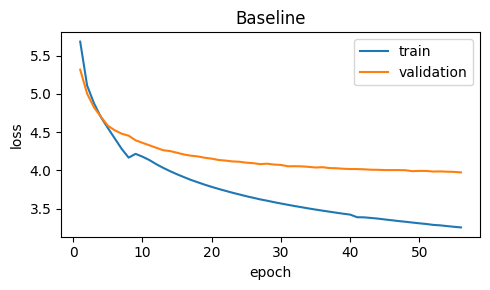

In [19]:
plot_loss(baseline_hist, "Baseline", "outputs/figures/training_baseline_loss.png")

The BLEU, chrF++ and repetition for this model on the 1000 sentence subset.

In [20]:
baseline_res = subset_result(baseline_config, baseline_model)
results.append(baseline_res)
pd.DataFrame([baseline_res])

,experiment,category,bleu,chrf_pp,rep_pct
0,baseline (Adam),Reference,7.9885,26.8619,10.1


Just as every experiment below is compared to this baseline Transformer, we first compare the baseline Transformer itself to the non-neural dictionary baseline from notebook 02. The dictionary number is its full-test score; for that simple model the subset and full-test scores agree closely, so the comparison is fair.

In [21]:
dict_base = pd.read_csv("outputs/tables/baseline_results.csv").iloc[0]
baseline_vs_dict = pd.DataFrame([
    {"system": "dictionary baseline", "bleu": round(float(dict_base["bleu"]), 2), "chrf_pp": round(float(dict_base["chrf_pp"]), 2)},
    {"system": "baseline Transformer", "bleu": baseline_res["bleu"], "chrf_pp": baseline_res["chrf_pp"]},
])
baseline_vs_dict

,system,bleu,chrf_pp
0,dictionary baseline,4.7800,25.6500
1,baseline Transformer,7.9885,26.8619


The two metrics for the dictionary baseline and the baseline Transformer, side by side.

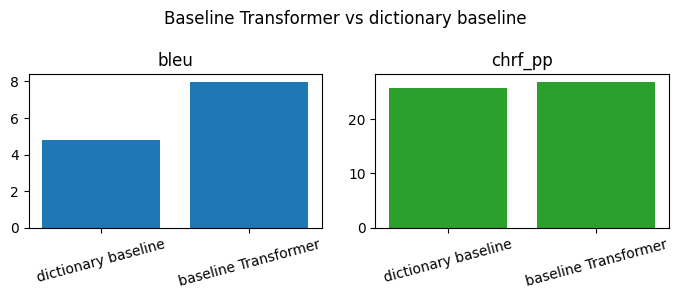

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, m, color in zip(axes, ["bleu", "chrf_pp"], ["tab:blue", "tab:green"]):
    ax.bar(baseline_vs_dict["system"], baseline_vs_dict[m], color=color)
    ax.set_title(m); ax.tick_params(axis="x", rotation=15)
fig.suptitle("Baseline Transformer vs dictionary baseline")
fig.tight_layout(); fig.savefig("outputs/figures/training_baseline_vs_dictionary.png"); plt.show()

The tiny Transformer beats the trivial dictionary baseline on BLEU, but only barely on chrF++. That small margin is exactly what motivates the ablation study: without better regularization and decoding, a from-scratch tiny model is not clearly better than a non-neural lookup.

Greedy/loss is weak and repetitive; this is the floor every other experiment is measured against.